https://github.com/keisen/tf-keras-vis

# Preparation

Load libraries

In [ ]:
%reload_ext autoreload
%autoreload 2

import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline

import tensorflow as tf
from tf_keras_vis.utils import num_of_gpus

_, gpus = num_of_gpus()
print('Tensorflow recognized {} GPUs'.format(gpus))

Tensorflow recognized 0 GPUs


Load tf.keras.Model

In [2]:
from tensorflow.keras.applications.resnet import ResNet50 as Model  #   <----

model = Model(weights='imagenet', include_top=True)
model.summary()

Model: "resnet50"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv1_pad (ZeroPadding2D)      (None, 230, 230, 3)  0           ['input_1[0][0]']                
                                                                                                  
 conv1_conv (Conv2D)            (None, 112, 112, 64  9472        ['conv1_pad[0][0]']              
                                )                                                                 
                                                                                           

Load and preprocess images

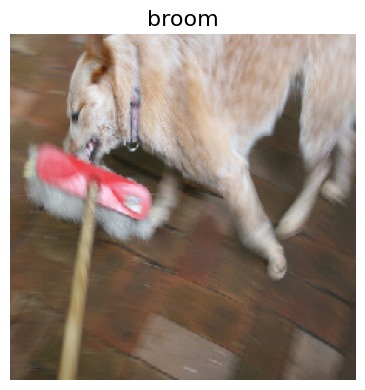

In [8]:
from tensorflow.keras.preprocessing.image import load_img
from tensorflow.keras.applications.resnet import preprocess_input   #   <----

# Image titles
#image_titles = ['Goldfish', 'Bear', 'Assault rifle']
image_titles = ['castle'] #   <----

# Load images and Convert them to a Numpy array
img1 = load_img('../image_stage2/23_castle_483_483.JPEG', target_size=(224, 224)) #   <----
#img2 = load_img('../images/sax.JPEG', target_size=(224, 224))           #   <----
#img3 = load_img('../images/green-lizard.JPEG', target_size=(224, 224))  #   <----
images = np.asarray([np.array(img1)])

# Preparing input data for given Model
X = preprocess_input(images)

# Rendering
f, ax = plt.subplots(nrows=1, ncols=1, figsize=(4, 4))  # ncols auf 1 setzen für ein Bild
ax.set_title(image_titles[0], fontsize=16)  # Nur das erste Bild
ax.imshow(images[0])  # Nur das erste Bild
ax.axis('off')
plt.tight_layout()
plt.show()

# Implement functions required to use attentions


Model modifier

In [9]:
from tf_keras_vis.utils.model_modifiers import ReplaceToLinear

replace2linear = ReplaceToLinear()

# Instead of using the ReplaceToLinear instance above,
# you can also define the function from scratch as follows:
def model_modifier_function(cloned_model):
    cloned_model.layers[-1].activation = tf.keras.activations.linear

Score function

In [10]:
from tf_keras_vis.utils.scores import CategoricalScore
#predicted class
pred_class_id = 207     #   <----

# 1 is the imagenet index corresponding to Goldfish, 294 to Bear and 413 to Assault Rifle.
#score = CategoricalScore([1, 294, 413])
score = CategoricalScore([pred_class_id])    #   <----

# Instead of using CategoricalScore object,
# you can also define the function from scratch as follows:
def score_function(output):
    # The `output` variable refers to the output of the model,
    # so, in this case, `output` shape is `(3, 1000)` i.e., (samples, classes).
    return (output[0][pred_class_id])  #   <----

GradCAM

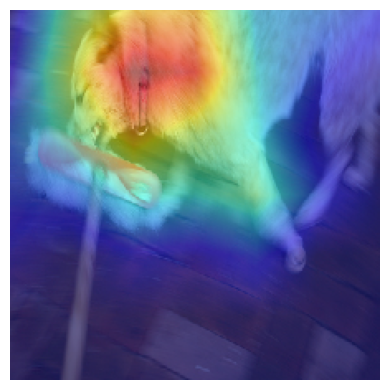

CPU times: total: 3.73 s
Wall time: 1.59 s


In [11]:
%%time

from matplotlib import cm
from tf_keras_vis.gradcam import Gradcam

# Create Gradcam object
gradcam = Gradcam(model,
                  model_modifier=replace2linear,
                  clone=True)

# Generate heatmap with GradCAM
cam = gradcam(score,
              X,
              penultimate_layer=-1)

## Since v0.6.0, calling `normalize()` is NOT necessary.
# cam = normalize(cam)

# Render
f, ax = plt.subplots(nrows=1, ncols=1, figsize=(4, 4))  # ncols auf 1 setzen für ein Bild

# Nur das erste Bild und den zugehörigen Titel verwenden
heatmap = np.uint8(cm.jet(cam[0])[..., :3] * 255)
#ax.set_title(image_titles[0], fontsize=16)
ax.imshow(images[0])
ax.imshow(heatmap, cmap='jet', alpha=0.5)  # overlay
ax.axis('off')

plt.tight_layout()
plt.show()

GradCAM++

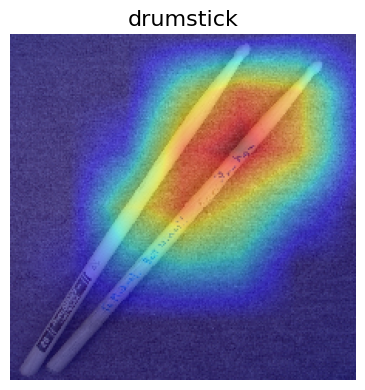

CPU times: total: 4.16 s
Wall time: 2.02 s


In [50]:
%%time

from tf_keras_vis.gradcam_plus_plus import GradcamPlusPlus

# Create GradCAM++ object
gradcam = GradcamPlusPlus(model,
                          model_modifier=replace2linear,
                          clone=True)

# Generate heatmap with GradCAM++
cam = gradcam(score,
              X,
              penultimate_layer=-1)

## Since v0.6.0, calling `normalize()` is NOT necessary.
# cam = normalize(cam)

# Render
f, ax = plt.subplots(nrows=1, ncols=1, figsize=(4, 4))  # ncols auf 1 setzen für ein Bild

# Nur das erste Bild und den zugehörigen Titel verwenden
heatmap = np.uint8(cm.jet(cam[0])[..., :3] * 255)
ax.set_title(image_titles[0], fontsize=16)
ax.imshow(images[0])
ax.imshow(heatmap, cmap='jet', alpha=0.5)  # overlay
ax.axis('off')

plt.tight_layout()
plt.show()

Vanilla Saliency

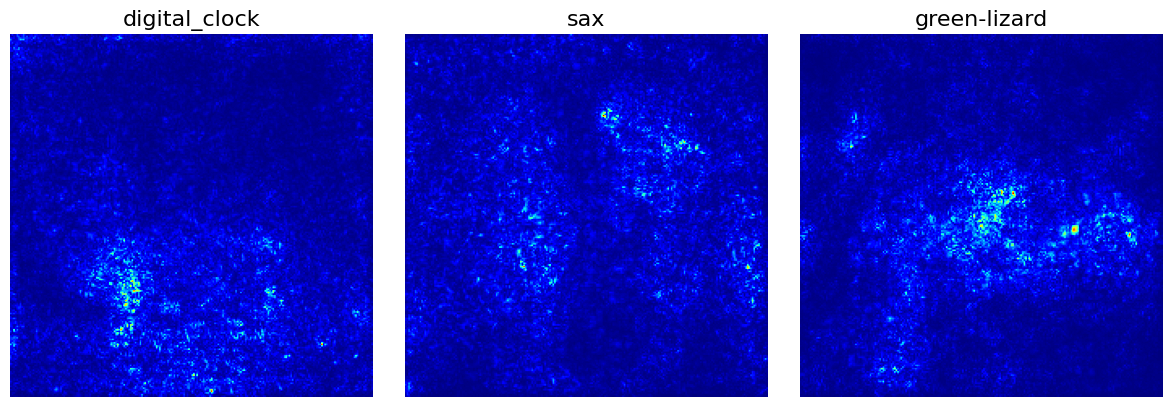

CPU times: total: 5.75 s
Wall time: 1.83 s


In [7]:
%%time
from tensorflow.keras import backend as K
from tf_keras_vis.saliency import Saliency
# from tf_keras_vis.utils import normalize

# Create Saliency object.
saliency = Saliency(model,
                    model_modifier=replace2linear,
                    clone=True)

# Generate saliency map
saliency_map = saliency(score, X)

## Since v0.6.0, calling `normalize()` is NOT necessary.
# saliency_map = normalize(saliency_map)

# Render
f, ax = plt.subplots(nrows=1, ncols=3, figsize=(12, 4))
for i, title in enumerate(image_titles):
    ax[i].set_title(title, fontsize=16)
    ax[i].imshow(saliency_map[i], cmap='jet')
    ax[i].axis('off')
plt.tight_layout()
plt.show()

SmoothGrad

FileNotFoundError: [Errno 2] No such file or directory: 'images/smoothgrad.png'

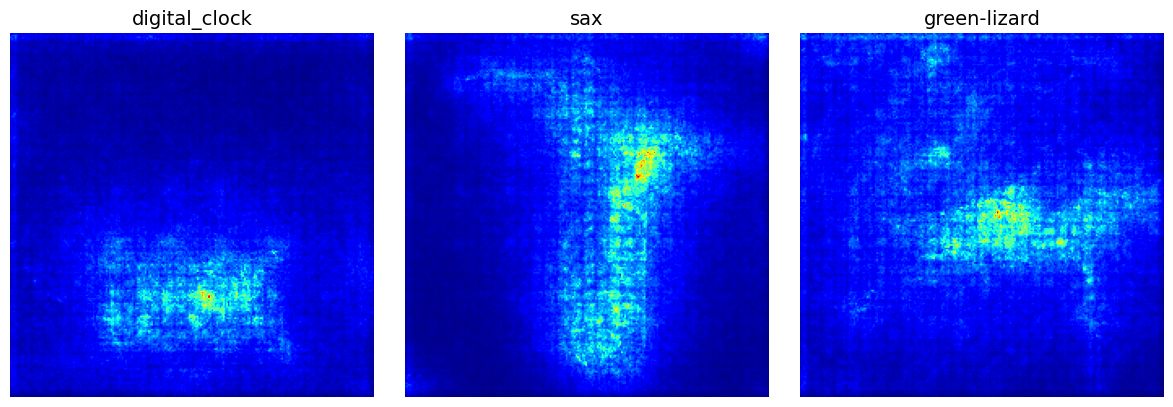

In [ ]:
%%time

# Generate saliency map with smoothing that reduce noise by adding noise
saliency_map = saliency(score,
                        X,
                        smooth_samples=20, # The number of calculating gradients iterations.
                        smooth_noise=0.20) # noise spread level.

## Since v0.6.0, calling `normalize()` is NOT necessary.
# saliency_map = normalize(saliency_map)

# Render
f, ax = plt.subplots(nrows=1, ncols=3, figsize=(12, 4))
for i, title in enumerate(image_titles):
    ax[i].set_title(title, fontsize=14)
    ax[i].imshow(saliency_map[i], cmap='jet')
    ax[i].axis('off')
plt.tight_layout()
#plt.savefig('images/smoothgrad.png')
plt.show()
